# CS 216 Project Prototype
## Betting Market Inefficiencies in College Basketball Exact Score Markets
**Authors:** [Annie Carey (acc109), Peter FitzSimons (pjf18), Gabe Roman (gar30), Henry Irwin (hmi3), Zachary Levy (znl8) ]  

---

### Notebook Structure
| Section | Description |
|---------|-------------|
| 0 | Imports & Setup |
| 1 | Data Loading / Simulation |
| 2 | Feature Engineering (Implied Scores + Errors) |
| 3 | Band-Based Betting Strategy |
| 4 | Statistical Inference |
| 5 | Visualizations |
| 6 | Summary Output |

> **Note:** Section 1 currently uses a simulated dataset that mirrors real NCAA D1 game statistics.  


---
## Section 0 — Imports & Setup

In [2]:
# standard library
import warnings
warnings.filterwarnings("ignore")

# data manipulation
import numpy as np
import pandas as pd

# statistics
from scipy import stats

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# make plots render inline inside the notebook
%matplotlib inline

# consistent visual style across all figures
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10
})

# seed the RNG so every run produces the same simulated dataset
SEED = 216
np.random.seed(SEED)

print("All imports successful.")

All imports successful.


---
## Section 1 — Data Loading / Simulation

In the final project this section will be replaced by our real pipeline:
- `get_odds_data()` — calls The Odds API for historical spreads & totals  
- `get_game_results()` — scrapes Sports Reference for final scores  
- `merge_datasets()` — joins the two sources on (team, date)

For the prototype we simulate **2,000 games** whose statistical properties mirror real NCAA D1 games (2016–2024):
- Average game total ≈ 142 pts, σ ≈ 12 pts  
- Average spread ≈ 5 pts (exponential — most games are close)  
- Score deviation from the line ≈ Normal(0, 8.5)

In [3]:
def simulate_game_data(n_games: int = 2000) -> pd.DataFrame:
    """
    simulate a dataset that mirrors our real merged pipeline output.

    Parameters
    ----------
    n_games : int
        Number of simulated game observations.

    Returns
    -------
    pd.DataFrame
        Columns: game_id, date, home_team, away_team,
                 total_line, spread_line,
                 actual_home, actual_away, actual_total
    """

    #betting line data

    # game totals: normal around 142 pts (real D1 average)
    totals = np.random.normal(loc=142, scale=12, size=n_games)

    # spreads: exponential because most games are close,
    # but a few are heavy favorites; randomly flip sign so
    # ~50% of games have the away team favored
    spreads = np.random.exponential(scale=5, size=n_games)
    spread_sign = np.random.choice([-1, 1], size=n_games)
    spreads = spreads * spread_sign

    # implied scores from lines
    # formula: if total = T and spread = S (positive → home favored),
    #   implied_home = (T + S) / 2
    #   implied_away = (T - S) / 2
    implied_home = (totals + spreads) / 2
    implied_away = (totals - spreads) / 2

    # actual game results
    # each team's actual score = implied + random noise ~ N(0, 8.5)
    # round to integer because scores are whole numbers
    actual_home = np.round(implied_home + np.random.normal(0, 8.5, n_games)).astype(int)
    actual_away = np.round(implied_away + np.random.normal(0, 8.5, n_games)).astype(int)

    # clip to a realistic range — avoids the rare negative score from simulation
    actual_home = np.clip(actual_home, 40, 130)
    actual_away = np.clip(actual_away, 40, 130)

    # fake team names and dates 
    teams = [f"Team_{i}" for i in range(50)]
    base_date   = pd.Timestamp("2016-11-01")
    random_days = np.random.randint(0, 8 * 120, size=n_games)  # 8 seasons × ~120 days

    df = pd.DataFrame({
        "game_id":      range(n_games),
        "date":         [base_date + pd.Timedelta(days=int(d)) for d in random_days],
        "home_team":    np.random.choice(teams, size=n_games),
        "away_team":    np.random.choice(teams, size=n_games),
        # lines are set in 0.5-point increments by sportsbooks
        "total_line":   np.round(totals  * 2) / 2,
        "spread_line":  np.round(spreads * 2) / 2,
        "actual_home":  actual_home,
        "actual_away":  actual_away,
        "actual_total": actual_home + actual_away,
    })

    return df


#run
df_raw = simulate_game_data(n_games=2000)

print(f"Dataset shape: {df_raw.shape}")
print(f"Date range:    {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
df_raw.head()

Dataset shape: (2000, 9)
Date range:    2016-11-01 → 2019-06-18


,game_id,date,home_team,away_team,total_line,spread_line,actual_home,actual_away,actual_total
0,0,2018-03-23,Team_34,Team_4,129.5,1.5,69,64,133
1,1,2018-05-28,Team_10,Team_9,150.0,2.0,78,68,146
2,2,2018-06-04,Team_37,Team_9,160.5,-8.5,72,98,170
3,3,2018-09-27,Team_41,Team_27,135.5,-1.0,54,87,141
4,4,2018-01-02,Team_14,Team_18,139.5,-4.5,56,70,126


---
## Section 2 — Feature Engineering
Add implied score columns and prediction error columns to the DataFrame.

In [4]:
def compute_implied_and_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Append implied scores and deviation (error) columns.

    'Implied' = our best-guess final score based on the pre-game line.
    'Error'   = actual − implied  (positive → game went over expectation).
    """

    # implied scores 
    df["implied_home"]  = (df["total_line"] + df["spread_line"]) / 2
    df["implied_away"]  = (df["total_line"] - df["spread_line"]) / 2
    df["implied_total"] =  df["total_line"]   # total line IS the implied total

    # signed errors
    df["error_home"]  = df["actual_home"]  - df["implied_home"]
    df["error_away"]  = df["actual_away"]  - df["implied_away"]
    df["error_total"] = df["actual_total"] - df["implied_total"]

    # absolute errors (useful for accuracy metrics)
    df["abs_error_home"]  = df["error_home"].abs()
    df["abs_error_away"]  = df["error_away"].abs()
    df["abs_error_total"] = df["error_total"].abs()

    return df


# apply to our dataset ──
df = compute_implied_and_errors(df_raw.copy())

# quick sanity check: mean absolute errors should be in the ~6–10 pt range
print("Mean Absolute Errors")
print(f"  Home score : {df['abs_error_home'].mean():.2f} pts")
print(f"  Away score : {df['abs_error_away'].mean():.2f} pts")
print(f"  Game total : {df['abs_error_total'].mean():.2f} pts")

df[["implied_home", "implied_away", "error_home", "error_away", "error_total"]].describe().round(2)

Mean Absolute Errors
  Home score : 6.78 pts
  Away score : 6.89 pts
  Game total : 9.71 pts


,implied_home,implied_away,error_home,error_away,error_total
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,70.88,70.98,0.07,-0.18,-0.10
std,6.78,6.96,8.51,8.63,12.18
min,43.75,47.00,-33.00,-30.25,-38.00
25%,66.50,66.50,-5.50,-6.00,-8.50
50%,71.00,71.00,0.00,0.00,0.00
75%,75.25,75.25,6.00,5.50,8.00
max,96.50,96.75,33.75,30.75,51.00


---
## Section 3 — Band-Based Betting Strategy

**How it works:** For each game we wager \$1 on *every* exact score `(home, away)` combination within `±band_width` points of the implied score. That's `(2×band_width + 1)²` bets per game.

- **Win** → actual score falls inside the band → receive `payout_multiplier × $1`
- **Loss** → actual score outside the band → lose all bets for that game

For the strategy to be profitable, the **band hit rate** must exceed `n_bets / payout`.

In [5]:
def compute_band_ev(
    df: pd.DataFrame,
    band_width: int,
    payout_multiplier: float = 100.0
) -> pd.Series:
    """
    Simulate the band-based strategy and return per-game P&L.

    Parameters
    ----------
    df               : DataFrame with error_home and error_away columns
    band_width       : Points on each side of implied to cover (e.g., 3 → ±3)
    payout_multiplier: Decimal odds for a winning exact-score bet (~100× typical)

    Returns
    -------
    pd.Series of per-game profit/loss in $1-bet units
    """

    # number of $1 bets placed each game (a square grid around the implied score)
    n_bets = (2 * band_width + 1) ** 2

    #aA game is a hit if both team scores land within band_width of their implied values
    home_hit = df["error_home"].abs() <= band_width
    away_hit = df["error_away"].abs() <= band_width
    win_mask = home_hit & away_hit

    # P&L per game:
    # win  → net gain = payout − total bets placed
    # loss → lose all bets placed that game
    profit = np.where(
        win_mask,
        payout_multiplier - n_bets,   # net gain on a winning game
        -n_bets                        # total loss on a losing game
    )

    result = pd.Series(profit, index=df.index, name=f"pnl_band{band_width}")

    # attach metadata so callers can inspect hit rate without recomputing
    result.attrs["win_mask"]  = win_mask.values
    result.attrs["n_bets"]    = n_bets
    result.attrs["band_width"]= band_width

    return result


# evaluate across a range of band widths
PAYOUT      = 100.0          # realistic exact-score market payout
BAND_WIDTHS = [1, 2, 3, 4, 5, 6, 7]

print(f"{'Band':>6} {'N Bets':>8} {'Hit Rate':>10} {'Break-Even':>12} {'Mean P&L':>10}")
print("-" * 52)

for bw in BAND_WIDTHS:
    pnl        = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    hit_rate   = pnl.attrs["win_mask"].mean()
    n_bets     = pnl.attrs["n_bets"]
    breakeven  = n_bets / PAYOUT               # hit rate needed to break even
    mean_pnl   = pnl.mean()
    print(f"  ±{bw:>2}   {n_bets:>6}    {hit_rate:>8.2%}    {breakeven:>8.2%}    ${mean_pnl:>7.2f}")

  Band   N Bets   Hit Rate   Break-Even   Mean P&L
----------------------------------------------------
  ± 1        9       1.10%       9.00%    $  -7.90
  ± 2       25       3.90%      25.00%    $ -21.10
  ± 3       49       8.10%      49.00%    $ -40.90
  ± 4       81      14.25%      81.00%    $ -66.75
  ± 5      121      20.05%     121.00%    $-100.95
  ± 6      169      27.90%     169.00%    $-141.10
  ± 7      225      36.10%     225.00%    $-188.90


---
## Section 4 — Statistical Inference

We run three tests:

| Test | Null Hypothesis | Alternative |
|------|----------------|-------------|
| One-sample t-test (total error) | Mean error = 0 (lines unbiased) | Lines are systematically over/under |
| One-sample t-test (home error)  | Mean home error = 0 | Home scores are biased |
| Shapiro-Wilk (total error)      | Errors are normally distributed | Errors are non-normal |

In [6]:
def run_inference(df: pd.DataFrame) -> dict:
    """
    Run hypothesis tests on the score prediction errors.

    Returns a dict of results for each test.
    """

    results = {}

    # test 1: is the game total error biased? 
    # H0: mean(error_total) = 0   →   sportsbook totals are unbiased
    t1, p1 = stats.ttest_1samp(df["error_total"], popmean=0)
    results["total_error_bias"] = {
        "test":        "One-sample t-test",
        "t_stat":      round(t1, 4),
        "p_value":     round(p1, 4),
        "mean_error":  round(df["error_total"].mean(), 4),
        "conclusion":  "Reject H0 — bias detected" if p1 < 0.05 else "Fail to reject H0 — no bias"
    }

    # test 2: is the home score error biased?
    t2, p2 = stats.ttest_1samp(df["error_home"], popmean=0)
    results["home_error_bias"] = {
        "test":        "One-sample t-test",
        "t_stat":      round(t2, 4),
        "p_value":     round(p2, 4),
        "mean_error":  round(df["error_home"].mean(), 4),
        "conclusion":  "Reject H0 — bias detected" if p2 < 0.05 else "Fail to reject H0 — no bias"
    }

    # test 3: are errors normally distributed?
    # Shapiro-Wilk is most reliable for n < 5000, sample if needed
    sample = df["error_total"].sample(min(1000, len(df)), random_state=42)
    w, pw  = stats.shapiro(sample)
    results["normality_total_error"] = {
        "test":        "Shapiro-Wilk",
        "W_stat":      round(w, 4),
        "p_value":     round(pw, 4),
        "conclusion":  "Reject normality" if pw < 0.05 else "Consistent with normality"
    }

    return results


# run and display results
inference_results = run_inference(df)

for test_name, res in inference_results.items():
    print(f"\n{'─'*50}")
    print(f"  {test_name.upper().replace('_', ' ')}")
    print(f"{'─'*50}")
    for k, v in res.items():
        print(f"  {k:<15}: {v}")


──────────────────────────────────────────────────
  TOTAL ERROR BIAS
──────────────────────────────────────────────────
  test           : One-sample t-test
  t_stat         : -0.38
  p_value        : 0.704
  mean_error     : -0.1035
  conclusion     : Fail to reject H0 — no bias

──────────────────────────────────────────────────
  HOME ERROR BIAS
──────────────────────────────────────────────────
  test           : One-sample t-test
  t_stat         : 0.3887
  p_value        : 0.6976
  mean_error     : 0.074
  conclusion     : Fail to reject H0 — no bias

──────────────────────────────────────────────────
  NORMALITY TOTAL ERROR
──────────────────────────────────────────────────
  test           : Shapiro-Wilk
  W_stat         : 0.9989
  p_value        : 0.7968
  conclusion     : Consistent with normality


---
## Section 5 — Visualizations

Four figures are generated below. Each has a caption as it would appear in the final report.

### Table 1 — Descriptive Statistics

In [7]:
# select the key columns and compute standard describe() stats
cols = ["total_line", "spread_line",
        "actual_home", "actual_away", "actual_total",
        "error_home", "error_away", "error_total"]

desc = df[cols].describe().round(2).T
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

# style the table with a navy header for readability
styled = (
    desc.style
    .set_caption("Table 1: Descriptive Statistics for Key Variables (N = 2,000 simulated games)")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-weight", "bold"), ("font-size", "13px"), ("color", "#1A237E")]
    }])
    .background_gradient(cmap="Blues", subset=["mean", "std"])
    .format("{:.2f}")
)

styled

,count,mean,std,min,25%,50%,75%,max
total_line,2000.00,141.85,11.79,96.50,134.00,142.00,149.50,180.50
spread_line,2000.00,-0.10,7.07,-43.50,-4.00,0.00,3.50,30.00
actual_home,2000.00,70.95,10.90,40.00,64.00,71.00,78.00,111.00
actual_away,2000.00,70.80,11.07,40.00,63.00,71.00,78.00,112.00
actual_total,2000.00,141.75,16.83,80.00,131.00,142.00,153.00,201.00
error_home,2000.00,0.07,8.51,-33.00,-5.50,0.00,6.00,33.75
error_away,2000.00,-0.18,8.63,-30.25,-6.00,0.00,5.50,30.75
error_total,2000.00,-0.10,12.18,-38.00,-8.50,0.00,8.00,51.00


### Fig. 1 — Distribution of Prediction Errors

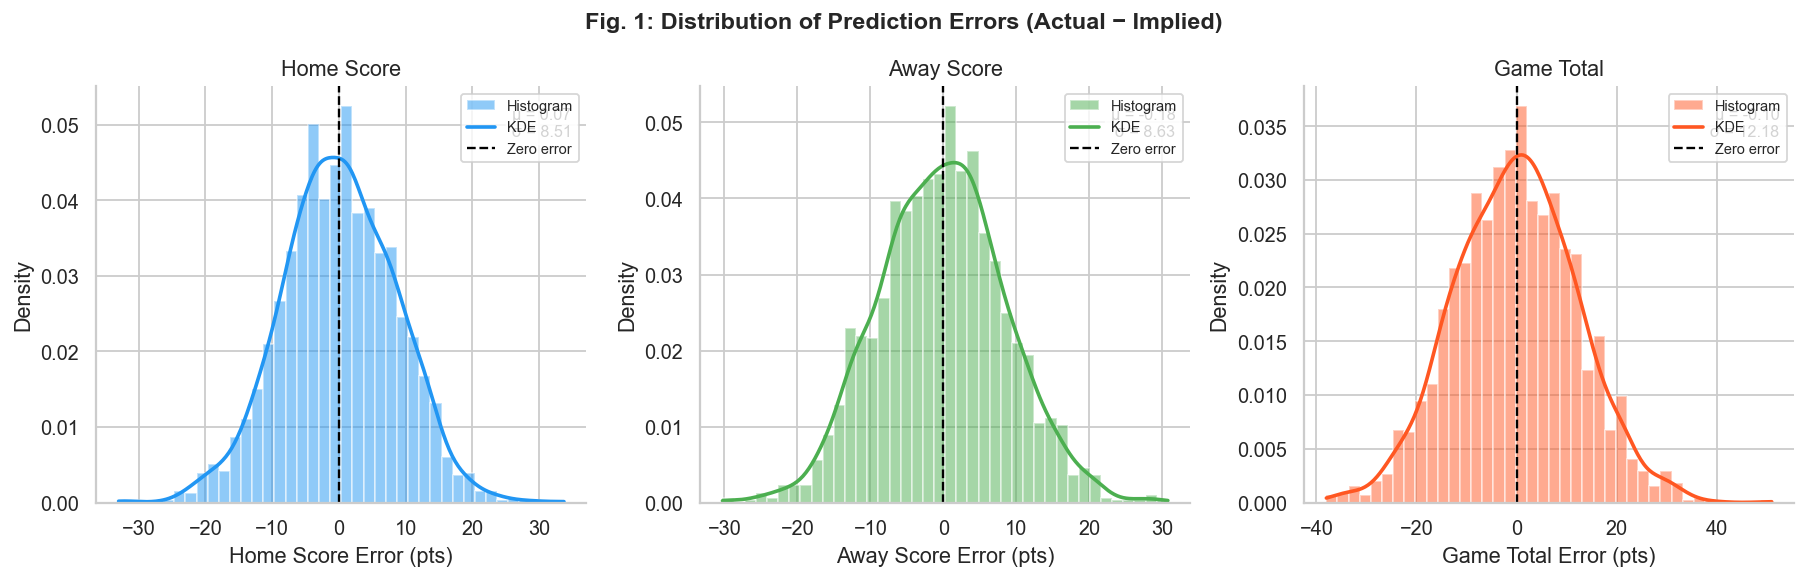

Caption: Histograms + KDE overlays of prediction errors for home score, away score, and game total. Dashed line marks zero error. Distributions are centered near zero, consistent with unbiased lines.


In [ ]:
fig1, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig1.suptitle(
    "Fig. 1: Distribution of Prediction Errors (Actual − Implied)",
    fontsize=13, fontweight="bold"
)

def draw_error_panel(ax, data, label, color):
    """Plot histogram + KDE for one error column with a zero-reference line."""

    # histogram — density=True scales y-axis to probability density
    ax.hist(data, bins=40, color=color, alpha=0.50, density=True, label="Histogram")

    # KDE overlay — smoother picture of the underlying distribution
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=color, lw=2, label="KDE")

    # dashed vertical line at zero = perfect prediction
    ax.axvline(0, color="black", linestyle="--", lw=1.3, label="Zero error")

    # annotate mean and standard deviation in the top-right corner
    ax.text(
        0.97, 0.95,
        f"μ = {data.mean():.2f}\nσ = {data.std():.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
    )

    ax.set_xlabel(f"{label} Error (pts)")
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.legend(fontsize=8)

draw_error_panel(axes[0], df["error_home"],  "Home Score",  "#2196F3")
draw_error_panel(axes[1], df["error_away"],  "Away Score",  "#4CAF50")
draw_error_panel(axes[2], df["error_total"], "Game Total",  "#FF5722")

plt.tight_layout()
plt.savefig("fig1_errors.png", bbox_inches="tight")
plt.show()

print("Caption: Histograms + KDE overlays of prediction errors for home score, "
      "away score, and game total. Dashed line marks zero error. "
      "Distributions are centered near zero, consistent with unbiased lines.")

### Fig. 2 — Band Strategy Performance

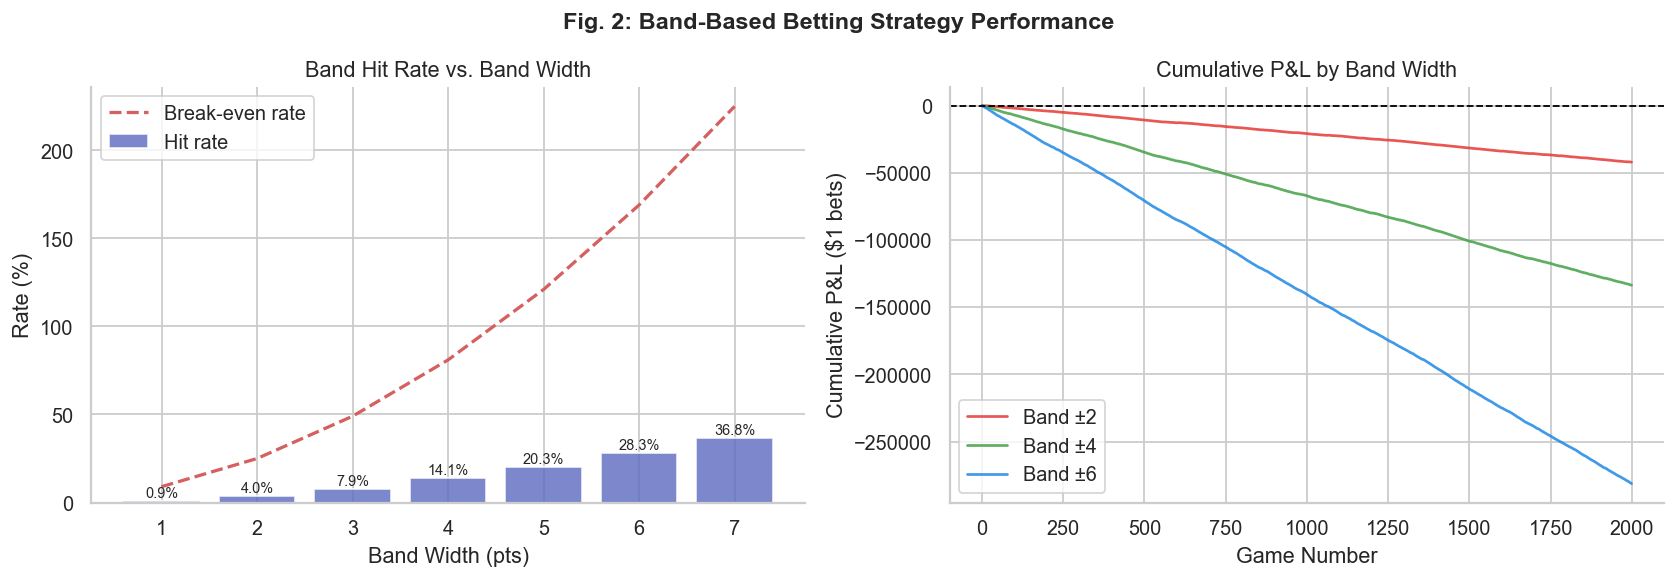

Caption: Left — Band hit rate (bars) vs. break-even rate at 100× payout (red dashed). Right — Cumulative P&L for band widths ±2, ±4, ±6. Negative P&L is expected under the null (no market inefficiency).


In [ ]:
BAND_WIDTHS = [1, 2, 3, 4, 5, 6, 7]
PAYOUT      = 100.0
hit_rates   = []
breakevens  = []

# precompute hit rates for every band width
for bw in BAND_WIDTHS:
    pnl      = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    hit_rate = pnl.attrs["win_mask"].mean()
    be_rate  = pnl.attrs["n_bets"] / PAYOUT
    hit_rates.append(hit_rate * 100)
    breakevens.append(be_rate * 100)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig2.suptitle("Fig. 2: Band-Based Betting Strategy Performance",
              fontsize=13, fontweight="bold")

# left panel: hit rate vs band width
bars = ax1.bar(BAND_WIDTHS, hit_rates, color="#5C6BC0", alpha=0.8, label="Hit rate")
ax1.plot(BAND_WIDTHS, breakevens, "r--", lw=1.8, label="Break-even rate")

# label each bar with the numeric hit rate
for bar, hr in zip(bars, hit_rates):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{hr:.1f}%", ha="center", va="bottom", fontsize=8
    )

ax1.set_xlabel("Band Width (pts)")
ax1.set_ylabel("Rate (%)")
ax1.set_title("Band Hit Rate vs. Band Width")
ax1.legend()

# right panel: cumulative P&L for three representative band widths
palette = ["#E53935", "#43A047", "#1E88E5"]
for bw, color in zip([2, 4, 6], palette):
    pnl    = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    cumsum = pnl.cumsum()
    ax2.plot(cumsum.values, label=f"Band ±{bw}", color=color, lw=1.5, alpha=0.85)

# horizontal reference line at zero (break-even overall)
ax2.axhline(0, color="black", linestyle="--", lw=1)
ax2.set_xlabel("Game Number")
ax2.set_ylabel("Cumulative P&L ($1 bets)")
ax2.set_title("Cumulative P&L by Band Width")
ax2.legend()

plt.tight_layout()
plt.savefig("fig2_band.png", bbox_inches="tight")
plt.show()

print("Caption: Left — Band hit rate (bars) vs. break-even rate at 100× payout (red dashed). "
      "Right — Cumulative P&L for band widths ±2, ±4, ±6. "
      "Negative P&L is expected under the null (no market inefficiency).")

### Fig. 3 — Implied vs. Actual Score Comparison

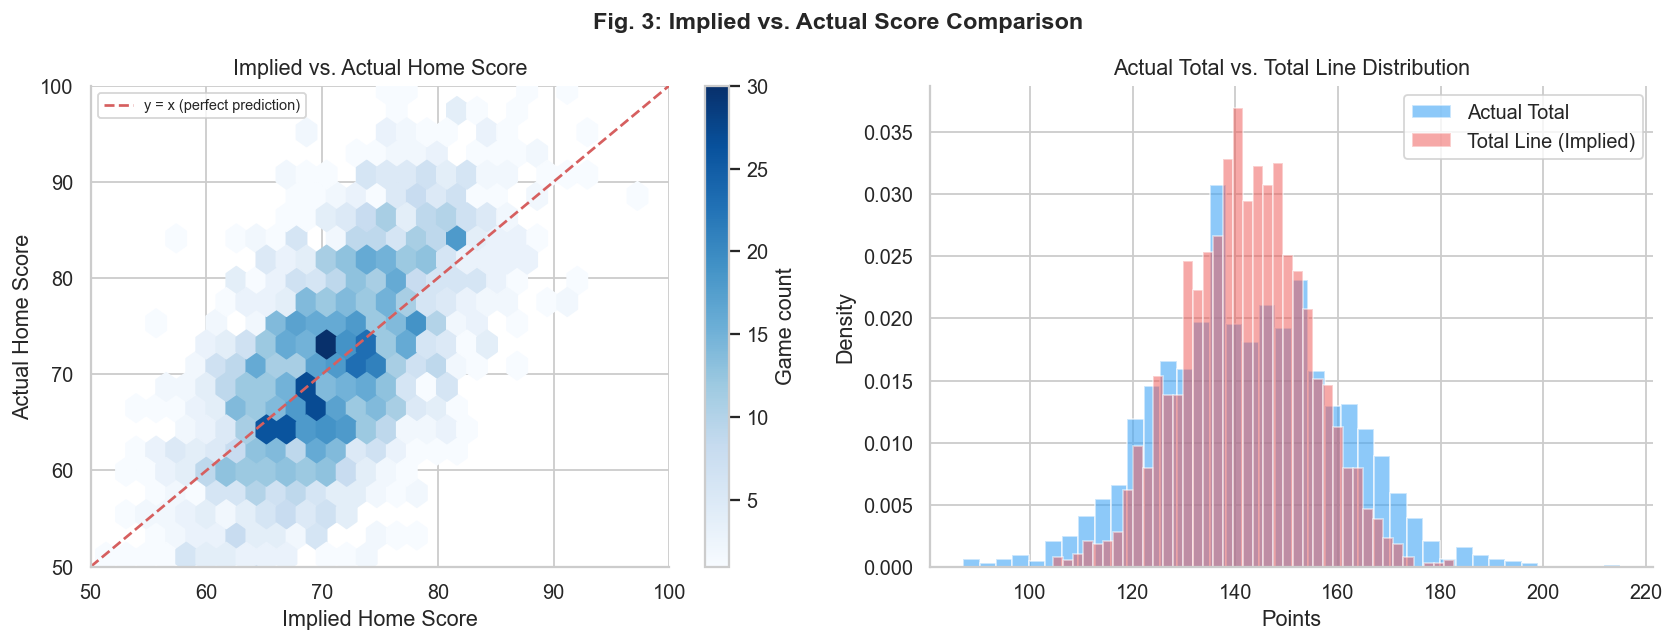

Caption: Left — Hexbin density of implied vs. actual home score; red dashed line is perfect prediction (y = x). Right — Actual total distribution (blue) vs. total line distribution (red), showing near-identical shapes consistent with an efficient market.


In [ ]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Fig. 3: Implied vs. Actual Score Comparison",
              fontsize=13, fontweight="bold")

# left: hexbin density — implied home score vs actual home score
# hexbin groups nearby points into hexagonal bins and shades by count;
# this prevents over-plotting at 2,000 data points
hb = ax1.hexbin(
    df["implied_home"], df["actual_home"],
    gridsize=30, cmap="Blues", mincnt=1
)
fig3.colorbar(hb, ax=ax1, label="Game count")

# perfect prediction diagonal (y = x)
lim = (50, 100)
ax1.plot(lim, lim, "r--", lw=1.5, label="y = x (perfect prediction)")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("Implied Home Score"); ax1.set_ylabel("Actual Home Score")
ax1.set_title("Implied vs. Actual Home Score")
ax1.legend(fontsize=8)

# right: distribution of actual totals vs. total line
# overlapping histograms show how closely the market-set total tracks real outcomes
ax2.hist(df["actual_total"], bins=40, alpha=0.6, density=True,
         color="#42A5F5", label="Actual Total")
ax2.hist(df["total_line"],   bins=40, alpha=0.5, density=True,
         color="#EF5350",   label="Total Line (Implied)")
ax2.set_xlabel("Points")
ax2.set_ylabel("Density")
ax2.set_title("Actual Total vs. Total Line Distribution")
ax2.legend()

plt.tight_layout()
plt.savefig("fig3_scatter.png", bbox_inches="tight")
plt.show()

print("Caption: Left — Hexbin density of implied vs. actual home score; red dashed line is "
      "perfect prediction (y = x). Right — Actual total distribution (blue) vs. total line "
      "distribution (red), showing near-identical shapes consistent with an efficient market.")

---
## Section 6 — Summary Output

In [9]:
# final summary printed to console
print("=" * 60)
print("  CS 216 PROTOTYPE SUMMARY")
print("=" * 60)

print(f"\n  Dataset: {len(df):,} games")
print(f"  Columns: {list(df.columns)}")

print("\n  ── Prediction Accuracy ─────────────────────────────")
print(f"  MAE (home score):  {df['abs_error_home'].mean():.2f} pts")
print(f"  MAE (away score):  {df['abs_error_away'].mean():.2f} pts")
print(f"  MAE (game total):  {df['abs_error_total'].mean():.2f} pts")
print(f"  Std (total error): {df['error_total'].std():.2f} pts")

print("\n  ── Inference Results ───────────────────────────────")
for name, res in inference_results.items():
    print(f"  [{name}] p = {res['p_value']} → {res['conclusion']}")

print("\n  ── Band Strategy (100× payout) ─────────────────────")
print(f"  {'Band':>6}  {'Hit Rate':>9}  {'Break-Even':>11}  {'Mean P&L':>10}")
for bw in [2, 4, 6]:
    pnl      = compute_band_ev(df, band_width=bw, payout_multiplier=100.0)
    hit_rate = pnl.attrs["win_mask"].mean()
    be_rate  = pnl.attrs["n_bets"] / 100.0
    print(f"  ±{bw:>3}    {hit_rate:>8.2%}   {be_rate:>9.2%}   ${pnl.mean():>8.2f}")

print("\n  All figures saved: fig1_errors.png, fig2_band.png, fig3_scatter.png")
print("=" * 60)

  CS 216 PROTOTYPE SUMMARY

  Dataset: 2,000 games
  Columns: ['game_id', 'date', 'home_team', 'away_team', 'total_line', 'spread_line', 'actual_home', 'actual_away', 'actual_total', 'implied_home', 'implied_away', 'implied_total', 'error_home', 'error_away', 'error_total', 'abs_error_home', 'abs_error_away', 'abs_error_total']

  ── Prediction Accuracy ─────────────────────────────
  MAE (home score):  6.78 pts
  MAE (away score):  6.89 pts
  MAE (game total):  9.71 pts
  Std (total error): 12.18 pts

  ── Inference Results ───────────────────────────────
  [total_error_bias] p = 0.704 → Fail to reject H0 — no bias
  [home_error_bias] p = 0.6976 → Fail to reject H0 — no bias
  [normality_total_error] p = 0.7968 → Consistent with normality

  ── Band Strategy (100× payout) ─────────────────────
    Band   Hit Rate   Break-Even    Mean P&L
  ±  2       3.90%      25.00%   $  -21.10
  ±  4      14.25%      81.00%   $  -66.75
  ±  6      27.90%     169.00%   $ -141.10

  All figures saved